# Phase 1: Standalone Clarification Subgraph (SRS Subagent)
This notebook implements **Phase 1** of `SRS_Subgraph_Implementation_Plan.md`.
It builds a stateful, multi-turn Human-in-the-Loop (HITL) requirements-gathering engine that extracts and formalizes software requirements into an IEEE 830-aligned model.

### Architectural Invariants:
1. **Zero-LLM Interrupt**: Question generation is decoupled from the `interrupt()` node to prevent token burn upon resume.
2. **Delta Requirements Merging**: Updates merge only the latest human answer into the existing model, keeping token costs flat.
3. **Forced Gap Enumeration**: Completeness checks require explicit identification of ambiguities before declaring saturation.


In [15]:
import os
import sys
import json
import time
import asyncio
import operator
from pathlib import Path
from typing import TypedDict, Annotated, List, Dict, Any, Optional, Literal

from dotenv import load_dotenv, dotenv_values
from pydantic import BaseModel, Field

# Ensure workspace root is in python path
sys.path.insert(0, os.getcwd())

# LangChain & LangGraph primitives
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

# ---------------------------------------------------------------------------
# 1. Environment & Configuration
# ---------------------------------------------------------------------------
env_path = os.path.join(os.getcwd(), ".env")
load_dotenv(dotenv_path=env_path, override=True)
env_vals = dotenv_values(env_path)

class Config:
    def __init__(self):
        self.google_api_key = (env_vals.get("GOOGLE_API_KEY") or os.getenv("GOOGLE_API_KEY") or "").strip().strip('"').strip("'")
        self.openrouter_api_key = (env_vals.get("OPENROUTER_API_KEY") or os.getenv("OPENROUTER_API_KEY") or "").strip().strip('"').strip("'")
        
        # LangSmith Tracing
        self.langsmith_tracing = os.getenv("LANGSMITH_TRACING", "true").lower() == "true"
        self.langsmith_project = os.getenv("LANGSMITH_PROJECT", "DevDocs-AI")
        os.environ["LANGCHAIN_PROJECT"] = self.langsmith_project
        
        print(f"✓ Configuration loaded. LangSmith Project: '{self.langsmith_project}'")

config = Config()

# ---------------------------------------------------------------------------
# 2. Resilient LLM Client Initialization
# ---------------------------------------------------------------------------
if config.google_api_key:
    from langchain_google_genai import ChatGoogleGenerativeAI
    llm = ChatGoogleGenerativeAI(
        model="gemini-3.5-flash",
        google_api_key=config.google_api_key,
        temperature=0,
        request_timeout=120.0
    )
    print("✓ Initialized ChatGoogleGenerativeAI (gemini-2.5-flash) - Fast & Zero Queue")
elif config.openrouter_api_key:
    from langchain_openrouter import ChatOpenRouter
    llm = ChatOpenRouter(
        model="nvidia/nemotron-3.5-lightning:free",
        temperature=0,
        api_key=config.openrouter_api_key,
        request_timeout=180.0,
        max_retries=3
    )
    print("✓ Initialized ChatOpenRouter (with 180s request_timeout)")


✓ Configuration loaded. LangSmith Project: 'doxer_ai'
✓ Initialized ChatGoogleGenerativeAI (gemini-2.5-flash) - Fast & Zero Queue


## 2. Requirements Models & Clarification State
Defines the typed Pydantic models for structured requirements extraction and the LangGraph `ClarificationState`.

- `RequirementsModel`: Structured target model (Actors, FRs, NFRs, Constraints).
- `CompletenessCheck`: Output of the auditor, forcing gap enumeration before boolean status.
- `ClarificationState`: The subgraph state schema.

In [16]:
# ---------------------------------------------------------------------------
# Core Requirements Models (IEEE 830 compliant)
# ---------------------------------------------------------------------------
class Actor(BaseModel):
    name: str = Field(description="Name of the user role or external system")
    description: str = Field(description="Role responsibilities and access permissions")

class FunctionalRequirement(BaseModel):
    req_id: str = Field(description="Unique identifier e.g. FR-001")
    title: str = Field(description="Short, descriptive title")
    description: str = Field(description="Detailed requirement description")
    priority: Literal["Must Have", "Should Have", "Could Have"] = Field(
        default="Must Have", 
        description="Requirement priority"
    )
    acceptance_criteria: list[str] = Field(
        default_factory=list,
        description="Testable conditions that satisfy the requirement"
    )

class NonFunctionalRequirement(BaseModel):
    category: Literal["Performance", "Security", "Scalability", "Reliability", "Usability"] = Field(
        description="NFR category"
    )
    description: str = Field(description="Specific quantifiable constraint")
    metric: Optional[str] = Field(
        default=None, 
        description="Measurable target e.g. 'p99 latency < 200ms at 5000 RPS'"
    )

class RequirementsModel(BaseModel):
    project_title: str = Field(default="Software System", description="Title of the project")
    project_scope: str = Field(default="", description="High-level product vision and operational boundaries")
    target_users_and_actors: list[Actor] = Field(default_factory=list)
    functional_requirements: list[FunctionalRequirement] = Field(default_factory=list)
    non_functional_requirements: list[NonFunctionalRequirement] = Field(default_factory=list)
    system_constraints: list[str] = Field(
        default_factory=list, 
        description="Technical stack, regulatory, or environment rules"
    )
    assumptions_and_dependencies: list[str] = Field(
        default_factory=list,
        description="Underlying assumptions and third-party dependencies"
    )

# ---------------------------------------------------------------------------
# Completeness Auditor Schema
# ---------------------------------------------------------------------------
class CompletenessCheck(BaseModel):
    reasoning: str = Field(
        description="Step-by-step audit of current requirements against standard IEEE 830 dimensions"
    )
    missing_areas: list[str] = Field(
        description="Explicit list of ambiguous or missing dimensions. MUST be populated before deciding is_complete."
    )
    is_complete: bool = Field(
        description="True ONLY if no critical functional or architectural ambiguities remain"
    )
    next_question: Optional[str] = Field(
        default=None, 
        description="A targeted, clear question focusing on the highest-priority missing area. None if is_complete is True."
    )

# ---------------------------------------------------------------------------
# Clarification Subgraph State Schema
# ---------------------------------------------------------------------------
class ClarificationState(TypedDict):
    user_prompt: str
    project_context: Optional[str]
    conversation_log: Annotated[list[dict], operator.add]
    turn_count: int
    max_turns: int
    requirements: RequirementsModel
    completeness: Optional[CompletenessCheck]
    unresolved_gaps: list[str]

print("✓ Core data models & ClarificationState successfully defined.")


✓ Core data models & ClarificationState successfully defined.


## 3. Initial Requirements Bootstrap Node (`analyze_initial_requirements`)
Parses the user's raw opening prompt and project context into the first structured `RequirementsModel`.
Instructs the model to extract explicit facts and leave ambiguous areas blank for the completeness auditor to probe.


In [17]:
# ---------------------------------------------------------------------------
# Node: analyze_initial_requirements
# ---------------------------------------------------------------------------
INITIAL_ANALYSIS_SYSTEM_PROMPT = """You are a Principal Software Systems Architect initializing an IEEE 830 Software Requirements Specification (SRS).
Your job is to analyze the user's initial project prompt and any provided technical context, and construct an initial structured RequirementsModel.

Guidelines:
1. Extract all explicit functional and non-functional requirements.
2. Identify user roles and external system actors.
3. Identify known system constraints (tech stack, regulatory, database preferences) and assumptions.
4. DO NOT hallucinate or invent specific architectural decisions if the user has not mentioned them. Leave ambiguous areas empty or general so the completeness auditor can clarify them with the user.
5. Provide clear, professional requirement descriptions with testable acceptance criteria where applicable.
"""

def analyze_initial_requirements(state: ClarificationState) -> dict:
    user_prompt = state["user_prompt"]
    context = state.get("project_context") or "No additional context provided."
    
    prompt = f"""Project Prompt:
{user_prompt}

Additional Context:
{context}

Extract and structure the initial requirements model from this information."""
    
    structured_llm = llm.with_structured_output(RequirementsModel)
    
    seeded_model = structured_llm.invoke([
        SystemMessage(content=INITIAL_ANALYSIS_SYSTEM_PROMPT),
        HumanMessage(content=prompt)
    ])
    
    # Ensure project_title is populated
    if not seeded_model.project_title or seeded_model.project_title == "Software System":
        seeded_model.project_title = user_prompt.split("\n")[0][:60]
        
    return {
        "requirements": seeded_model,
        "conversation_log": [{"role": "user", "content": user_prompt}],
        "turn_count": 0,
        "unresolved_gaps": []
    }

print("✓ analyze_initial_requirements node defined.")


✓ analyze_initial_requirements node defined.


In [18]:
# # Quick validation test for analyze_initial_requirements
# sample_input: ClarificationState = {
#     "user_prompt": "We need an automated invoice reconciliation microservice that matches bank transactions against ERP invoices and flags discrepancies.",
#     "project_context": "Python FastAPI backend, PostgreSQL database, Docker containerized.",
#     "conversation_log": [],
#     "turn_count": 0,
#     "max_turns": 5,
#     "requirements": RequirementsModel(),
#     "completeness": None,
#     "unresolved_gaps": []
# }

# test_result = analyze_initial_requirements(sample_input)
# model: RequirementsModel = test_result["requirements"]

# print(f"Project Title : {model.project_title}")
# print(f"Scope         : {model.project_scope[:120]}...")
# print(f"Actors found  : {[a.name for a in model.target_users_and_actors]}")
# print(f"FRs found     : {[f'{fr.req_id}: {fr.title}' for fr in model.functional_requirements]}")
# print(f"Constraints   : {model.system_constraints}")


## 4. Completeness Auditor Node (`check_completeness`)
Audits the structured `RequirementsModel` against IEEE 830 standards.
Forces the LLM to populate `missing_areas` before outputting `is_complete`.
Pre-computes `next_question` so the interrupt node does not invoke any LLM upon resumption.


In [19]:
# ---------------------------------------------------------------------------
# Node: check_completeness
# ---------------------------------------------------------------------------
COMPLETENESS_AUDIT_SYSTEM_PROMPT = """You are a Lead Systems Auditor evaluating an IEEE 830 Software Requirements Specification (SRS).
Your job is to audit the current structured RequirementsModel for completeness, clarity, and architectural soundness.

IEEE 830 Core Dimensions to Check:
1. Target Users & Actors: Are roles and external integrations clearly identified?
2. Functional Scope: Are core workflows, data flows, and edge cases defined with clear acceptance criteria?
3. Non-Functional Requirements: Are performance, security (auth/RBAC), and reliability quantified with measurable metrics?
4. Technical Constraints: Are tech stacks, data storage mechanisms, or regulatory requirements specified?

Operational Rules:
- Enumerate every specific ambiguity or gap in `missing_areas` FIRST.
- If critical dimensions remain undefined and the user has not yet reached turn limits, set `is_complete = False`.
- In `next_question`, ask exactly ONE crisp, prioritized, highly actionable question targeting the most critical missing area.
- If the core system boundaries and critical requirements are well-defined, set `is_complete = True` and `next_question = None`.
"""

def check_completeness(state: ClarificationState) -> dict:
    reqs: RequirementsModel = state["requirements"]
    turn_count = state.get("turn_count", 0)
    max_turns = state.get("max_turns", 5)
    
    # Format current model into an easily auditable summary
    model_summary = f"""Project Title: {reqs.project_title}
Scope: {reqs.project_scope}

Actors:
{json.dumps([a.model_dump() for a in reqs.target_users_and_actors], indent=2)}

Functional Requirements:
{json.dumps([fr.model_dump() for fr in reqs.functional_requirements], indent=2)}

Non-Functional Requirements:
{json.dumps([nfr.model_dump() for nfr in reqs.non_functional_requirements], indent=2)}

System Constraints:
{json.dumps(reqs.system_constraints, indent=2)}

Current Turn: {turn_count} / {max_turns}
"""

    audit_prompt = f"""Review the current requirements model below and perform your completeness audit:
{model_summary}
"""
    
    structured_auditor = llm.with_structured_output(CompletenessCheck)
    
    completeness: CompletenessCheck = structured_auditor.invoke([
        SystemMessage(content=COMPLETENESS_AUDIT_SYSTEM_PROMPT),
        HumanMessage(content=audit_prompt)
    ])
    
    # Safety guard: If turn count reached max_turns, force is_complete = True
    if turn_count >= max_turns:
        completeness.is_complete = True
        completeness.next_question = None
        
    return {
        "completeness": completeness
    }

print("✓ check_completeness node defined.")


✓ check_completeness node defined.


In [20]:
# # Quick validation test for check_completeness
# # We use the test_result from Cell 7 to check the seeded requirements
# audit_state: ClarificationState = {
#     "user_prompt": sample_input["user_prompt"],
#     "project_context": sample_input["project_context"],
#     "conversation_log": test_result["conversation_log"],
#     "turn_count": test_result["turn_count"],
#     "max_turns": 5,
#     "requirements": test_result["requirements"],
#     "completeness": None,
#     "unresolved_gaps": []
# }

# audit_output = check_completeness(audit_state)
# comp: CompletenessCheck = audit_output["completeness"]

# print(f"Is Complete    : {comp.is_complete}")
# print(f"Reasoning      : {comp.reasoning[:140]}...")
# print(f"Missing Areas  : {comp.missing_areas}")
# print(f"Next Question  : {comp.next_question}")

## 5. Human Interrupt & Delta-Update Nodes
- `ask_question`: Zero-LLM node using LangGraph's `interrupt()` primitive. Execution pauses until human resumes with `Command(resume=...)`.
- `update_requirements`: Flat-cost delta updater. Takes the current `RequirementsModel` and merges ONLY the latest human answer, avoiding $O(N^2)$ conversation token growth.


In [21]:
# ---------------------------------------------------------------------------
# Node: ask_question (Zero-LLM Human-in-the-Loop Interrupt)
# ---------------------------------------------------------------------------
def ask_question(state: ClarificationState) -> dict:
    completeness: CompletenessCheck = state["completeness"]
    question = completeness.next_question or "Could you clarify additional system requirements?"
    
    # Execution halts right here.
    # LangGraph persists the state and waits for external Command(resume=answer)
    human_answer = interrupt(question)
    
    return {
        "conversation_log": [
            {"role": "assistant", "content": question},
            {"role": "human", "content": str(human_answer)}
        ],
        "turn_count": state.get("turn_count", 0) + 1
    }

print("✓ ask_question (zero-LLM interrupt) node defined.")

# ---------------------------------------------------------------------------
# Node: update_requirements (Flat-cost Delta Merger)
# ---------------------------------------------------------------------------
DELTA_UPDATE_SYSTEM_PROMPT = """You are a Requirements Engineering Lead updating an IEEE 830 RequirementsModel based on a developer's latest clarification answer.

Rules:
1. You are given the CURRENT RequirementsModel and the LATEST question and answer.
2. Incorporate all new details: update or add functional requirements, add actors, specify NFR metrics, or record system constraints.
3. Preserve all existing valid requirements—do not drop or overwrite previously established requirements unless the user explicitly contradicted them.
4. Keep requirement IDs consistent (e.g. FR-001, FR-002, NFR-001).
5. Ensure acceptance criteria and metrics reflect the new information provided.
"""

def update_requirements(state: ClarificationState) -> dict:
    current_reqs: RequirementsModel = state["requirements"]
    
    # Extract the latest clarification Q&A from the conversation log
    log = state.get("conversation_log", [])
    latest_user_answer = "No user answer recorded."
    latest_question = "Clarify requirements."
    
    if len(log) >= 2 and log[-1].get("role") == "human":
        latest_user_answer = log[-1]["content"]
        latest_question = log[-2]["content"]
    elif len(log) >= 1 and log[-1].get("role") == "human":
        latest_user_answer = log[-1]["content"]

    update_prompt = f"""Current Requirements Model:
{json.dumps(current_reqs.model_dump(), indent=2)}

Latest Clarification Question Asked:
"{latest_question}"

Developer's Answer Provided:
"{latest_user_answer}"

Produce the updated, merged RequirementsModel incorporating this latest clarification."""

    structured_updater = llm.with_structured_output(RequirementsModel)
    
    updated_reqs: RequirementsModel = structured_updater.invoke([
        SystemMessage(content=DELTA_UPDATE_SYSTEM_PROMPT),
        HumanMessage(content=update_prompt)
    ])
    
    return {
        "requirements": updated_reqs
    }

print("✓ update_requirements node defined.")


✓ ask_question (zero-LLM interrupt) node defined.
✓ update_requirements node defined.


In [22]:
# # Quick validation test for update_requirements delta merging
# # Simulate a human responding to the auditor's question about authentication & roles
# simulated_human_answer = "We must use OAuth2 with JWT bearer tokens. Roles needed: Admin (full access), Finance Reviewer (read and reconcile only), and System Service (API ingest)."

# test_delta_state: ClarificationState = {
#     "user_prompt": sample_input["user_prompt"],
#     "project_context": sample_input["project_context"],
#     "conversation_log": [
#         {"role": "assistant", "content": comp.next_question or "What auth mechanism?"},
#         {"role": "human", "content": simulated_human_answer}
#     ],
#     "turn_count": 1,
#     "max_turns": 5,
#     "requirements": test_result["requirements"],
#     "completeness": comp,
#     "unresolved_gaps": []
# }

# delta_result = update_requirements(test_delta_state)
# updated_model: RequirementsModel = delta_result["requirements"]

# print(f"Total Actors Now : {len(updated_model.target_users_and_actors)} -> {[a.name for a in updated_model.target_users_and_actors]}")
# print(f"Total FRs Now    : {len(updated_model.functional_requirements)} -> {[fr.title for fr in updated_model.functional_requirements]}")
# print(f"Constraints Now  : {updated_model.system_constraints}")


## 6. Deterministic Routing Guard (`route_after_completeness`)
Controls the lifecycle of the clarification loop:
- Exits to `END` if requirements are complete.
- Exits to `END` if `turn_count >= max_turns` (capturing remaining missing areas into `unresolved_gaps`).
- Routes to `ask_question` if clarification is needed and turns remain.


In [23]:
# ---------------------------------------------------------------------------
# Conditional Edge: route_after_completeness
# ---------------------------------------------------------------------------
def route_after_completeness(state: ClarificationState) -> str:
    completeness: Optional[CompletenessCheck] = state.get("completeness")
    turn_count = state.get("turn_count", 0)
    max_turns = state.get("max_turns", 5)
    
    # 1. Successful saturation
    if completeness and completeness.is_complete:
        print(f"\n✨ [Router] Requirements fully saturated at turn {turn_count}/{max_turns}. Routing to END.")
        return END
        
    # 2. Hard turn cap reached
    if turn_count >= max_turns:
        print(f"\n⚠️ [Router] Turn cap ({max_turns}) reached. Exiting clarification.")
        if completeness and completeness.missing_areas:
            state["unresolved_gaps"] = list(completeness.missing_areas)
            print(f"   Carrying forward {len(state['unresolved_gaps'])} unresolved gaps into state['unresolved_gaps'].")
        return END
        
    # 3. Continue clarification
    print(f"\n🔄 [Router] Ambiguities detected ({len(completeness.missing_areas) if completeness else 0} gaps). Routing to 'ask_question' (Turn {turn_count + 1}/{max_turns}).")
    return "ask_question"

print("✓ route_after_completeness defined.")


✓ route_after_completeness defined.


## 7. Clarification Subgraph Assembly & Compilation
Wires together:
- Nodes: `analyze_initial_requirements`, `check_completeness`, `ask_question`, `update_requirements`
- Edges:
  - `START -> analyze_initial_requirements -> check_completeness`
  - `check_completeness -> [route_after_completeness] -> (END | ask_question)`
  - `ask_question -> update_requirements -> check_completeness`
- Compiles with in-memory checkpointer (`MemorySaver`) to enable pause/resume across turns.


In [24]:
# ---------------------------------------------------------------------------
# Clarification Subgraph Builder & Compilation
# ---------------------------------------------------------------------------
clarification_builder = StateGraph(ClarificationState)

# 1. Register Nodes
clarification_builder.add_node("analyze_initial_requirements", analyze_initial_requirements)
clarification_builder.add_node("check_completeness", check_completeness)
clarification_builder.add_node("ask_question", ask_question)
clarification_builder.add_node("update_requirements", update_requirements)

# 2. Register Edges
clarification_builder.add_edge(START, "analyze_initial_requirements")
clarification_builder.add_edge("analyze_initial_requirements", "check_completeness")

# Conditional edge from auditor
clarification_builder.add_conditional_edges(
    "check_completeness",
    route_after_completeness,
    {
        "ask_question": "ask_question",
        END: END
    }
)

# Clarification feedback loop
clarification_builder.add_edge("ask_question", "update_requirements")
clarification_builder.add_edge("update_requirements", "check_completeness")

# 3. Compile with Checkpointer for standalone HITL support
clarification_checkpointer = MemorySaver()
clarification_graph = clarification_builder.compile(checkpointer=clarification_checkpointer)

print("✓ clarification_graph successfully compiled with MemorySaver checkpointer.")


✓ clarification_graph successfully compiled with MemorySaver checkpointer.


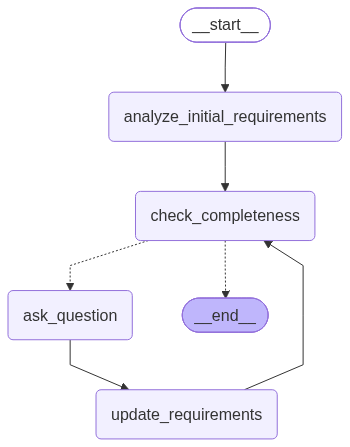

In [25]:
# Visualize the compiled graph topology
from IPython.display import Image, display

try:
    display(Image(clarification_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(clarification_graph.get_graph().draw_ascii())


## 8. Interactive Multi-Turn HITL Execution Test
Tests the full Human-in-the-Loop clarification session.
- Demonstrates how LangGraph pauses at `interrupt()`.
- Reads `state.tasks[0].interrupts[0].value` to retrieve the question.
- Demonstrates resuming via `clarification_graph.invoke(Command(resume=answer), config=config)`.


In [26]:
# # ---------------------------------------------------------------------------
# # Demonstration: Step-by-Step State Inspection & Resume
# # ---------------------------------------------------------------------------
# thread_id = f"test-session-{int(time.time())}"
# config = {"configurable": {"thread_id": thread_id}}

# print(f"--- 1. Starting Session (thread_id: {thread_id}) ---")
# initial_input = {
#     "user_prompt": "We need a real-time IoT delivery fleet tracker for 5,000 trucks. Trucks send telemetry (GPS coordinates, speed, cabin temperature).",
#     "project_context": "Go or Python backend, TimescaleDB, Kafka.",
#     "conversation_log": [],
#     "turn_count": 0,
#     "max_turns": 3,
#     "requirements": RequirementsModel(),
#     "completeness": None,
#     "unresolved_gaps": []
# }

# # Run until the first interrupt
# clarification_graph.invoke(initial_input, config=config)

# # Inspect paused state
# state = clarification_graph.get_state(config)
# print(f"Is graph paused? {'YES' if state.next else 'NO'}")
# print(f"Next Node to execute: {state.next}")

# # Retrieve the question raised by interrupt()
# pending_question = state.tasks[0].interrupts[0].value
# print(f"\n[Agent Question 1]:\n{pending_question}\n")

# # Resume with a simulated response
# print("--- 2. Resuming with Human Answer ---")
# human_response_1 = "Trucks stream telemetry via MQTT into Kafka every 5 seconds. We need alerts triggered within 2 seconds if refrigerated cargo temperature rises above 4°C."

# clarification_graph.invoke(Command(resume=human_response_1), config=config)

# # Check state after resumption
# state = clarification_graph.get_state(config)
# if state.next:
#     next_q = state.tasks[0].interrupts[0].value
#     print(f"\n[Agent Question 2]:\n{next_q}\n")
    
#     # Resume again
#     human_response_2 = "Authentication: Devices authenticate via mutual TLS (mTLS) with X.509 certs. Backend API users authenticate with OAuth2 JWT. Admin and Fleet Dispatcher roles."
#     clarification_graph.invoke(Command(resume=human_response_2), config=config)

# state_final = clarification_graph.get_state(config)
# print(f"\nFinal Graph Status: {'PAUSED' if state_final.next else 'COMPLETED'}")
# print(f"Total Turns: {state_final.values.get('turn_count')}")
# print(f"Functional Requirements Extracted: {len(state_final.values['requirements'].functional_requirements)}")
# for fr in state_final.values['requirements'].functional_requirements:
#     print(f"  • [{fr.req_id}] {fr.title}: {fr.description[:80]}...")


In [27]:
# ---------------------------------------------------------------------------
# Interactive Helper: Chat directly with your Clarification Agent
# ---------------------------------------------------------------------------
def run_interactive_clarification(prompt: str, context: str = None, max_turns: int = 4):
    """Runs a live interactive clarification session in the notebook using input()."""
    t_id = f"interactive-{int(time.time())}"
    cfg = {"configurable": {"thread_id": t_id}}
    
    print("=" * 70)
    print(f"🚀 Launching Clarification Session [Max Turns: {max_turns}]")
    print("=" * 70)
    
    # 1. Seed initial run
    clarification_graph.invoke({
        "user_prompt": prompt,
        "project_context": context,
        "conversation_log": [],
        "turn_count": 0,
        "max_turns": max_turns,
        "requirements": RequirementsModel(),
        "completeness": None,
        "unresolved_gaps": []
    }, config=cfg)
    
    # 2. Conversational loop
    while True:
        curr_state = clarification_graph.get_state(cfg)
        
        # If no next node, graph has completed
        if not curr_state.next:
            print("\n🎉 Clarification Completed!")
            break
            
        # Extract question from interrupt
        question = curr_state.tasks[0].interrupts[0].value
        print(f"\n🤖 Agent (Turn {curr_state.values.get('turn_count', 0) + 1}/{max_turns}):")
        print(f"{question}\n")
        
        # Prompt user in notebook
        user_reply = input("👤 You (type 'exit' to abort): ")
        if user_reply.strip().lower() in ['exit', 'quit']:
            print("Session aborted by user.")
            return None
            
        # Resume the graph with user's reply
        clarification_graph.invoke(Command(resume=user_reply), config=cfg)
        
    final_reqs: RequirementsModel = curr_state.values["requirements"]
    print("\n" + "=" * 70)
    print(f"📋 FINAL REQUIREMENTS MODEL: {final_reqs.project_title}")
    print("=" * 70)
    print(f"Scope: {final_reqs.project_scope}\n")
    print("Actors:", [a.name for a in final_reqs.target_users_and_actors])
    print("Functional Requirements:")
    for fr in final_reqs.functional_requirements:
        print(f"  - [{fr.req_id}] {fr.title} ({fr.priority})")
        for ac in fr.acceptance_criteria:
            print(f"      * {ac}")
    print("Non-Functional Requirements:")
    for nfr in final_reqs.non_functional_requirements:
        print(f"  - [{nfr.category}] {nfr.description} (Metric: {nfr.metric})")
    print("System Constraints:", final_reqs.system_constraints)
    if curr_state.values.get("unresolved_gaps"):
        print("\n⚠️ Unresolved Gaps Carried Forward:", curr_state.values["unresolved_gaps"])
        
    return curr_state.values

# To run a live chat session, simply run:
# session_result = run_interactive_clarification("Build a decentralized peer-to-peer file sharing desktop app")


In [28]:
session_result = run_interactive_clarification("Build a Real time ride hailing application")


🚀 Launching Clarification Session [Max Turns: 4]

🔄 [Router] Ambiguities detected (5 gaps). Routing to 'ask_question' (Turn 1/4).

🤖 Agent (Turn 1/4):
How should the system handle ride cancellations by either the rider or the driver, specifically regarding cancellation windows, penalty fees, and automatic refund triggers?


🔄 [Router] Ambiguities detected (5 gaps). Routing to 'ask_question' (Turn 2/4).

🤖 Agent (Turn 2/4):
How should the system handle the verification and approval workflow for driver-uploaded documents (e.g., is it a manual Admin approval process, or does it integrate with an external background check API), and what is the driver's state before approval is granted?


🔄 [Router] Ambiguities detected (4 gaps). Routing to 'ask_question' (Turn 3/4).

🤖 Agent (Turn 3/4):
How should the system handle payment failures at the end of a ride (e.g., does the rider's account get locked, is there an automatic retry schedule, and how is the driver's payout affected)?


🔄 [Router] Am